In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import re
import lightgbm as lgb
from scipy.special import softmax
from sklearn.metrics import f1_score, classification_report
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\aakri\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\aakri\anaconda3\lib\site-packages\dask\dataframe\utils.py:366: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
C:\Users\aakri\anaconda3\lib\site-packages\dask\dataframe\utils.py:366: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
C:\Users\aakri\anaconda3\lib\site-packages\dask\dataframe\utils.py:366: FutureWarning: pandas.UInt64Index is deprecated and will be removed from p

In [2]:
#pip install pyarrow==2.0.0

## Import Data

In [3]:
train_df = pd.read_csv('processed_train.csv')
test_df = pd.read_csv('processed_test.csv')

## Feature Encoding

In [4]:
# select the Id/index
train_ids = train_df['ID']
# select the target
y = train_df['Target']
#select features
X = train_df.drop(columns=['ID', 'Target'])
X_test=test_df.drop(columns=['ID'])

# Define categorical features
cat_cols =['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 
           'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 
           'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers',
           'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records',
           'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important',
           'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money',
           'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card',
           'future_risk_theft_stock', 'motivation_make_more_money',
           'uses_friends_family_savings', 'uses_informal_lender','country_x_cashflow','country_x_insurance'
          ]
# Define numerical features
num_cols= [col for col in X.columns if col not in cat_cols]

In [5]:
# drop='first' is used to avoid the "dummy variable trap" (multicollinearity)
# sparse_output=False makes the result a standard array (easier to read)
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

################################################################################################################
# Create the full preprocessor
# We apply the cat_pipe ONLY to categorical columns. 
# Numerical columns can be kept 'passthrough' for now
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, cat_cols),
        ('num', 'passthrough', num_cols) # Keep numerical data as-is for now
    ],
    remainder='drop' # This drops the ID column automatically
)

# Transform data
X_processed = preprocessor.fit_transform(X)
X_test_processed=preprocessor.transform(X_test)

# Convert back to a DataFrame for readability
encoded_feature_names = preprocessor.get_feature_names_out()
X_final = pd.DataFrame(X_processed, columns=encoded_feature_names)
X_test_final = pd.DataFrame(X_test_processed, columns=encoded_feature_names)

## Dropped Columns that are not giving any useful information

In [6]:
X_final = X_final.drop(["cat__attitude_more_successful_next_year_don't know or n/a",
                        "cat__uses_friends_family_savings_don't know (do not show)",
                        "cat__uses_informal_lender_don't know (do not show)",
                        "cat__perception_insurance_important_don?t know / doesn?t apply",
                        "cat__perception_insurance_important_don't know",
                        "cat__has_internet_banking_don't know (do not show)",
                        "cat__has_mobile_money_used to have but don't have now",
                        "cat__compliance_income_tax_refused",
                        "cat__has_loan_account_don't know (do not show)"], axis=1)
X_test_processed= X_test_final.drop(["cat__attitude_more_successful_next_year_don't know or n/a",
                        "cat__uses_friends_family_savings_don't know (do not show)",
                        "cat__uses_informal_lender_don't know (do not show)",
                        "cat__perception_insurance_important_don?t know / doesn?t apply",
                        "cat__perception_insurance_important_don't know",
                        "cat__has_internet_banking_don't know (do not show)",
                        "cat__has_mobile_money_used to have but don't have now",
                        "cat__compliance_income_tax_refused",
                        "cat__has_loan_account_don't know (do not show)"], axis=1)

## More Features

In [7]:
X_final["financial_stress"] = (
    X_final["num__log_expenses"] / (X_final["num__log_income"] + 1)
) + (
    X_final["cat__problem_sourcing_money_yes"] * 1.5
) + (
    X_final["cat__current_problem_cash_flow_yes"] * 2
)

X_test_processed["financial_stress"] = (
    X_test_processed["num__log_expenses"] / (X_test_processed["num__log_income"] + 1)
) + (
    X_test_processed["cat__problem_sourcing_money_yes"] * 1.5
) + (
    X_test_processed["cat__current_problem_cash_flow_yes"] * 2
)

## Split For Training and Testing

In [8]:
# 1. First split: Separate out the final TEST set
X_temp, X_test, y_temp, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Second split: Split the remaining 'temp' data into TRAIN and VALIDATION
# Here, we take 20% of the remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

train_ids = train_df['ID']
test_ids = test_df['ID']

print(f"Training set:   {len(X_train)} rows")
print(f"Validation set: {len(X_val)} rows (Use this for Early Stopping)")
print(f"Testing set:    {len(X_test)} rows (The 'Blind' test)")

Training set:   6155 rows
Validation set: 1539 rows (Use this for Early Stopping)
Testing set:    1924 rows (The 'Blind' test)


In [9]:
## Define mapping
label_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# 2. Apply the mapping to your target arrays
y_train_encoded = y_train.map(label_mapping)
y_val_encoded = y_val.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

In [10]:
X_train_light=X_train.copy()
X_val_light=X_val.copy()
X_test_light=X_test.copy()

In [11]:
X_train_light.columns = [
    re.sub('[^0-9a-zA-Z]+', '_', col) for col in X_train.columns
]
X_test_light.columns = X_train_light.columns
X_val_light.columns = X_train_light.columns

In [12]:
X_test_processed.columns = [
    re.sub('[^0-9a-zA-Z]+', '_', col) for col in X_test_processed.columns
]
X_test_processed.columns = X_test_processed.columns

## Model 1: XGBoost

In [13]:
xgb_model = XGBClassifier(
    n_estimators=522,
    learning_rate=0.07104274945954676,
    max_depth=5,
    reg_alpha=1.0,  # L1 regularization
    reg_lambda=1.0, # L2 regularization
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    subsample=0.8819196018669633, 
    colsample_bytree=0.6425045795096875,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    enable_categorical=True,
    early_stopping_rounds=300
)

# Fit the pipeline

xgb_model.fit(X_train_light, y_train_encoded,eval_set=[(X_val_light, y_val_encoded)],
             verbose=False)
print(f"Best iteration: {xgb_model.best_iteration}")

C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:10:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


Best iteration: 156


## Getting Feature Importance

In [14]:
# 1. Get the underlying booster
booster = xgb_model.get_booster()
metrics = ['weight', 'gain', 'cover']
# 2. Get the scores for each type
for m in metrics:
    # Get the raw scores
    scores = booster.get_score(importance_type=m)
    
    # Sort the dictionary by value (highest first) and take the top 5
    top_5 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
    
    print(f"\n--- Top 5 Features by {m.upper()} ---")
    for feature, score in top_5:
        print(f"{feature}: {score:.4f}")


--- Top 5 Features by WEIGHT ---
num_profit_ratio: 2498.0000
num_owner_age: 2233.0000
financial_stress: 1972.0000
num_stability_index: 1901.0000
num_maturity: 1814.0000

--- Top 5 Features by GAIN ---
num_funeral_insurance: 28.5641
cat_country_x_insurance_lesotho_no: 14.7392
cat_country_x_cashflow_lesotho_yes: 10.1723
cat_country_x_insurance_zimbabwe_no: 10.0164
cat_country_x_insurance_malawi_no: 8.7155

--- Top 5 Features by COVER ---
cat_country_x_insurance_zimbabwe_no: 927.9193
cat_has_insurance_yes: 705.8786
cat_country_x_insurance_malawi_yes: 583.6591
num_funeral_insurance: 582.6285
cat_country_x_insurance_malawi_no: 505.0002


## Predict the test data

In [15]:
xgmb_pred = xgb_model.predict_proba(X_test_light)

## Model 2: Catboost

In [16]:
cat = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    iterations=1500,
    random_seed=42,
    verbose=200
)

cat.fit(
    X_train_light, y_train_encoded,
    eval_set=(X_val_light, y_val_encoded),
    use_best_model=True
)

cat_pred = cat.predict_proba(X_test_light)

0:	learn: 0.7511099	test: 0.7331779	best: 0.7331779 (0)	total: 191ms	remaining: 4m 46s
200:	learn: 0.8835038	test: 0.8724854	best: 0.8732124 (186)	total: 3.54s	remaining: 22.9s
400:	learn: 0.9008930	test: 0.8722531	best: 0.8733273 (255)	total: 7.94s	remaining: 21.8s
600:	learn: 0.9229839	test: 0.8696769	best: 0.8736928 (426)	total: 12s	remaining: 18s
800:	learn: 0.9382338	test: 0.8688058	best: 0.8736928 (426)	total: 15.9s	remaining: 13.9s
1000:	learn: 0.9509933	test: 0.8673291	best: 0.8736928 (426)	total: 19.8s	remaining: 9.86s
1200:	learn: 0.9592484	test: 0.8634949	best: 0.8736928 (426)	total: 23.4s	remaining: 5.83s
1400:	learn: 0.9665926	test: 0.8637210	best: 0.8736928 (426)	total: 27s	remaining: 1.91s
1499:	learn: 0.9697582	test: 0.8645460	best: 0.8736928 (426)	total: 28.9s	remaining: 0us

bestTest = 0.8736927906
bestIteration = 426

Shrink model to first 427 iterations.


## Model 3: Light GBM

In [17]:
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    learning_rate=0.09426419007154008,
    max_depth=-1,
    n_estimators=1200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    lambda_l1= 0.0004682657442436951,
    num_leaves= 52,
    feature_fraction= 0.5542747564886497,
    bagging_fraction= 0.607189665005347
)

lgbm.fit(X_train_light, y_train_encoded,eval_set=(X_val_light, y_val_encoded))
lgbm_pred = lgbm.predict_proba(X_test_light)

[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.5542747564886497
[LightGBM] [Warning] lambda_l1 is set=0.0004682657442436951, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004682657442436951
[LightGBM] [Warning] bagging_fraction is set=0.607189665005347, subsample=0.8 will be ignored. Current value: bagging_fraction=0.607189665005347
[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.5542747564886497
[LightGBM] [Warning] lambda_l1 is set=0.0004682657442436951, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004682657442436951
[LightGBM] [Warning] bagging_fraction is set=0.607189665005347, subsample=0.8 will be ignored. Current value: bagging_fraction=0.607189665005347
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003963 seconds.
You can set `force_r

## Score- F1

In [18]:
combined_probs = (0.2*xgmb_pred + 0.7*cat_pred + 0.1*lgbm_pred) 

final_preds = np.argmax(combined_probs, axis=1)


# Use 'macro' to see how you're doing across all three health levels
combined_f1 = f1_score(y_test_encoded, final_preds, average='macro')

print(f"Multiclass Combined F1: {combined_f1:.4f}")
print(classification_report(y_test_encoded, final_preds))

Multiclass Combined F1: 0.7925
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1256
           1       0.88      0.68      0.77       574
           2       0.90      0.55      0.68        94

    accuracy                           0.87      1924
   macro avg       0.88      0.74      0.79      1924
weighted avg       0.87      0.87      0.87      1924



## Feature Importance Graph

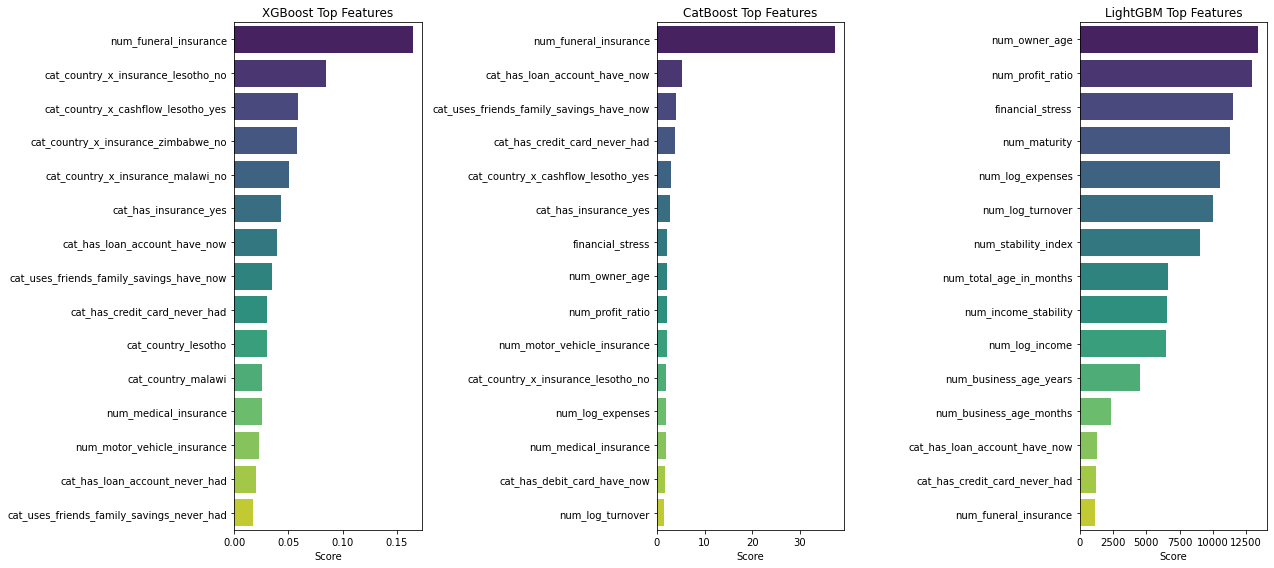

In [19]:
def plot_importance(models, model_names, feature_names, top_n=15):
    fig, axes = plt.subplots(1, len(models), figsize=(18, 8))
    
    for i, model in enumerate(models):
        # Extract importance
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
        else:
            # Fallback for models that might store it differently
            importances = model.get_feature_importances() 
            
        data = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False).head(top_n)
        
        sns.barplot(x='Importance', y='Feature', data=data, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{model_names[i]} Top Features')
        axes[i].set_xlabel('Score')
        axes[i].set_ylabel('')

    plt.tight_layout()
    plt.show()

# Usage (Replace with your actual model variables and column list)
plot_importance(
    models=[xgb_model, cat, lgbm],
    model_names=['XGBoost', 'CatBoost', 'LightGBM'],
    feature_names=X_train_light.columns
)

## Combining Scores

In [20]:
y_probs_xgb = xgb_model.predict_proba(X_test_processed)
y_probs_cat = cat.predict_proba(X_test_processed)
y_probs_lgm = lgbm.predict_proba(X_test_processed)

[LightGBM] [Warning] feature_fraction is set=0.5542747564886497, colsample_bytree=0.8 will be ignored. Current value: feature_fraction=0.5542747564886497
[LightGBM] [Warning] lambda_l1 is set=0.0004682657442436951, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0004682657442436951
[LightGBM] [Warning] bagging_fraction is set=0.607189665005347, subsample=0.8 will be ignored. Current value: bagging_fraction=0.607189665005347


In [21]:
final_preds_cal=0.55 * y_probs_cat + 0.35 * y_probs_xgb + 0.1 * y_probs_lgm
final_preds_cal

array([[0.95466611, 0.04311606, 0.00221781],
       [0.63671128, 0.36123815, 0.00205058],
       [0.92716723, 0.07061645, 0.00221632],
       ...,
       [0.00355391, 0.97635534, 0.02009075],
       [0.00806735, 0.94618028, 0.04575235],
       [0.97311142, 0.02554427, 0.00134432]])

In [22]:
final_preds_cal = softmax(final_preds_cal * 1.2, axis=1)

In [23]:
final_labels = np.argmax(final_preds_cal, axis=1)

In [24]:
# The original mapping
label_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Create the inverse mapping
reverse_mapping = {v: k for k, v in label_mapping.items()}

# Convert predictions
final_encoded = [reverse_mapping[pred] for pred in final_labels]

In [25]:
submission  = pd.DataFrame({
    'ID':test_ids,
    'Target':final_encoded})
submission.head()

,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Low
2,ID_V9OB3M,Low
3,ID_6OI9DI,Low
4,ID_H2TN8B,Low


In [26]:
submission['Target'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [27]:
submission['Target'].value_counts()

Low       1722
Medium     601
High        82
Name: Target, dtype: int64

In [28]:
submission.to_csv('submission.csv', index=False)
print("\nSuccess!  is ready for upload.")


Success!  is ready for upload.


## Hyper Parameter Selection- XGBoost

In [29]:
def objective(trial):
    # Define the hyperparameter search space
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }
    
    model = XGBClassifier(**param, random_state=42)
    model.fit(X_train_light, y_train_encoded)
    
    # Evaluate using the F1 score (better for imbalanced classes than Accuracy)
    preds = model.predict(X_test_light)
    return f1_score(y_test_encoded, preds, average='weighted')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best trial: {study.best_params}")

[I 2026-04-26 20:11:14,017] A new study created in memory with name: no-name-00f8f78c-13fc-4a7d-95a1-1e1396690a27
[I 2026-04-26 20:11:24,524] Trial 0 finished with value: 0.8662091500581915 and parameters: {'n_estimators': 834, 'max_depth': 8, 'learning_rate': 0.01620245514297764, 'subsample': 0.6370943059194415, 'colsample_bytree': 0.622929557371692}. Best is trial 0 with value: 0.8662091500581915.
[I 2026-04-26 20:11:31,412] Trial 1 finished with value: 0.8683155400734321 and parameters: {'n_estimators': 824, 'max_depth': 5, 'learning_rate': 0.01482934559225258, 'subsample': 0.8730173086104454, 'colsample_bytree': 0.8149452781732487}. Best is trial 1 with value: 0.8683155400734321.
[I 2026-04-26 20:11:35,937] Trial 2 finished with value: 0.868205305179953 and parameters: {'n_estimators': 690, 'max_depth': 4, 'learning_rate': 0.01035338450430948, 'subsample': 0.989736714631787, 'colsample_bytree': 0.6508288857003144}. Best is trial 1 with value: 0.8683155400734321.
[I 2026-04-26 20:11

Best trial: {'n_estimators': 306, 'max_depth': 3, 'learning_rate': 0.08059775139198336, 'subsample': 0.6061462393979675, 'colsample_bytree': 0.9529934936157962}


## Hyper Parameter Selection- CatBoost

In [30]:
def objective_cat(trial):
    param = {
        "objective": "MultiClass",
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 4, 10), # Reduced from 12 to 10
        "boosting_type": trial.suggest_categorical("boosting_type", ["Plain"]), # 'Plain' is safer for RAM
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "iterations": 1000,
        "used_ram_limit": "4gb", # Limits RAM usage to 4GB
        "eval_metric": "TotalF1",
        "random_seed": 42,
    }

    model = CatBoostClassifier(**param, silent=True)
    model.fit(X_train_light, y_train_encoded, early_stopping_rounds=50)
    
    preds = model.predict(X_test_light)
    return f1_score(y_test_encoded, preds, average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective_cat, n_trials=50)

print(f"Best trial: {study.best_params}")

[I 2026-04-26 20:15:32,000] A new study created in memory with name: no-name-07b799f2-99d6-401a-9492-429576517fcc
[I 2026-04-26 20:16:14,618] Trial 0 finished with value: 0.7710588343349271 and parameters: {'colsample_bylevel': 0.08225365507066953, 'depth': 9, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'learning_rate': 0.008175363955088017}. Best is trial 0 with value: 0.7710588343349271.
[I 2026-04-26 20:16:19,309] Trial 1 finished with value: 0.5474649963290298 and parameters: {'colsample_bylevel': 0.03210840135225966, 'depth': 4, 'boosting_type': 'Plain', 'bootstrap_type': 'Bernoulli', 'learning_rate': 0.004009492703758101}. Best is trial 0 with value: 0.7710588343349271.
[I 2026-04-26 20:16:23,038] Trial 2 finished with value: 0.6689015030047929 and parameters: {'colsample_bylevel': 0.014515632479252045, 'depth': 5, 'boosting_type': 'Plain', 'bootstrap_type': 'Bernoulli', 'learning_rate': 0.02118094931169079}. Best is trial 0 with value: 0.7710588343349271.
[I 2026-04-

Best trial: {'colsample_bylevel': 0.07895036797645172, 'depth': 5, 'boosting_type': 'Plain', 'bootstrap_type': 'MVS', 'learning_rate': 0.030254895632981452}


## Hyper Parameter Selection- LightGBM

In [31]:
def objective_lgb(trial):
    param = {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
    }

    model = lgb.LGBMClassifier(**param)
    model.fit(X_train_light, y_train_encoded,eval_set=[(X_test_light, y_test_encoded)],
              eval_metric="multi_logloss",callbacks=[lgb.early_stopping(50)])
    
    preds = model.predict(X_test_light)
    return f1_score(y_test_encoded, preds, average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective_lgb, n_trials=50)
print(f"Best trial: {study.best_params}")

[I 2026-04-26 20:25:29,578] A new study created in memory with name: no-name-31a731a3-b9c4-456f-a01b-8c8946881008


Training until validation scores don't improve for 50 rounds


[I 2026-04-26 20:25:31,226] Trial 0 finished with value: 0.7817862913191367 and parameters: {'lambda_l1': 0.520951518032329, 'num_leaves': 126, 'feature_fraction': 0.9774040563461953, 'bagging_fraction': 0.4357292050081749, 'learning_rate': 0.0787578886254837}. Best is trial 0 with value: 0.7817862913191367.


Early stopping, best iteration is:
[43]	valid_0's multi_logloss: 0.341132
Training until validation scores don't improve for 50 rounds


[I 2026-04-26 20:25:33,684] Trial 1 finished with value: 0.7878829626529424 and parameters: {'lambda_l1': 2.213708033261769e-07, 'num_leaves': 249, 'feature_fraction': 0.5112998868848925, 'bagging_fraction': 0.5729457837040839, 'learning_rate': 0.08919673212064716}. Best is trial 1 with value: 0.7878829626529424.


...

Early stopping, best iteration is:
[30]	valid_0's multi_logloss: 0.336669
Training until validation scores don't improve for 50 rounds


[I 2026-04-26 20:27:02,255] Trial 48 finished with value: 0.7952419340445798 and parameters: {'lambda_l1': 7.890604089208283e-05, 'num_leaves': 143, 'feature_fraction': 0.7110496031299463, 'bagging_fraction': 0.4893606091186155, 'learning_rate': 0.08860903397398516}. Best is trial 21 with value: 0.8030905159613569.


Early stopping, best iteration is:
[37]	valid_0's multi_logloss: 0.340123
Training until validation scores don't improve for 50 rounds


[I 2026-04-26 20:27:04,266] Trial 49 finished with value: 0.7952299158486893 and parameters: {'lambda_l1': 0.00038902707935330676, 'num_leaves': 175, 'feature_fraction': 0.8849887090487226, 'bagging_fraction': 0.4028009793710463, 'learning_rate': 0.07152646880590546}. Best is trial 21 with value: 0.8030905159613569.


Early stopping, best iteration is:
[39]	valid_0's multi_logloss: 0.337584
Best trial: {'lambda_l1': 1.8534654913185073e-05, 'num_leaves': 145, 'feature_fraction': 0.8215555184288944, 'bagging_fraction': 0.7149267570234112, 'learning_rate': 0.09990047856001276}


## Finding Weights

In [36]:
xgb_model = XGBClassifier(
    n_estimators=156,
    learning_rate=0.07104274945954676,
    max_depth=5,
    reg_alpha=1.0,  # L1 regularization
    reg_lambda=1.0, # L2 regularization
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    subsample=0.8819196018669633, 
    colsample_bytree=0.6425045795096875,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    enable_categorical=True
)

In [37]:
# Define your best-tuned models
estimators = [
    ('xgb', xgb_model),
    ('cat', cat),
    ('lgbm', lgbm)
]

# The Meta-Model finds the weights for you
stack_model = StackingClassifier(
    estimators=estimators, 
    final_estimator=LogisticRegression(),
    cv=5 # Cross-validation to prevent overfitting
)

stack_model.fit(X_train_light, y_train_encoded)

C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:37:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


0:	learn: 0.7511099	total: 30.9ms	remaining: 46.3s
200:	learn: 0.8835038	total: 2.94s	remaining: 19s
400:	learn: 0.9008930	total: 5.89s	remaining: 16.2s
600:	learn: 0.9229839	total: 8.89s	remaining: 13.3s
800:	learn: 0.9382338	total: 11.9s	remaining: 10.4s
1000:	learn: 0.9509933	total: 14.8s	remaining: 7.4s
1200:	learn: 0.9592484	total: 17.8s	remaining: 4.44s
1400:	learn: 0.9665926	total: 20.9s	remaining: 1.47s
1499:	learn: 0.9697582	total: 22.3s	remaining: 0us


C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:37:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:37:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [20:37:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\aakri\anaconda3\lib\site-packages\xgboost\core.py

0:	learn: 0.7662266	total: 15.4ms	remaining: 23.1s
200:	learn: 0.8837278	total: 3.39s	remaining: 21.9s
400:	learn: 0.9068357	total: 6.63s	remaining: 18.2s
600:	learn: 0.9309815	total: 10.1s	remaining: 15.1s
800:	learn: 0.9466410	total: 13.6s	remaining: 11.8s
1000:	learn: 0.9547163	total: 17s	remaining: 8.47s
1200:	learn: 0.9641848	total: 20.6s	remaining: 5.14s
1400:	learn: 0.9706416	total: 24s	remaining: 1.7s
1499:	learn: 0.9739669	total: 25.7s	remaining: 0us
0:	learn: 0.7867792	total: 16.9ms	remaining: 25.4s
200:	learn: 0.8838095	total: 3.29s	remaining: 21.3s
400:	learn: 0.9095867	total: 6.5s	remaining: 17.8s
600:	learn: 0.9294287	total: 9.74s	remaining: 14.6s
800:	learn: 0.9441481	total: 13s	remaining: 11.4s
1000:	learn: 0.9570442	total: 17.6s	remaining: 8.75s
1200:	learn: 0.9641634	total: 27.4s	remaining: 6.81s
1400:	learn: 0.9720923	total: 31.9s	remaining: 2.25s
1499:	learn: 0.9749908	total: 34.9s	remaining: 0us
0:	learn: 0.7933546	total: 17.4ms	remaining: 26.2s
200:	learn: 0.88506

StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              class_weight='balanced',
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.6425045795096875,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=True,
                                              eval_metric='mlogloss',
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importance_...
                                CatBoostClassifier(depth=6, eval_metric='TotalF1', iterations=1500, l2_leaf_reg=3, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=200)),
                               ('lgbm',
                                LGBMClassifier(bagging_fraction=0.607189665005347,
                                               colsample_bytree=0.8,
                                               feature_fraction=0.5542747564886497,
                                               lambda_l1=0.0004682657442436951,
                                               learning_rate=0.09426419007154008,
                                               n_estimators=1200, num_class=3,
                                               num_leaves=52,
                                               objective='multiclass',
                                               random_state=42,
                                               subsample=0.8))],
                   final_estimator=LogisticRegression())

In [38]:
# Access the final logistic regression (the 'Meta-Model')
meta_model = stack_model.final_estimator_

# These coefficients act as the 'Weights' for each class
# For multiclass, it shows weights for each model per class
print("Meta-Model Weights (Coefficients):")
print(meta_model.coef_)

Meta-Model Weights (Coefficients):
[[ 3.0920653  -1.43454962 -1.65773808  1.33369502  0.2083977  -1.54231478
   0.06830774  0.38561166 -0.45414145]
 [-1.12978632  1.6533994  -0.52584615  0.31988943 -0.04226228 -0.27986127
   0.0212356  -0.19711866  0.17364894]
 [-1.96227898 -0.21884979  2.18358423 -1.65358445 -0.16613541  1.82217605
  -0.08954333 -0.188493    0.28049251]]
